# SentinelVision AI
## Notebook 02 — Visual Video EDA

### Objective

Notebook 01 analyzed the metadata created by the data pipeline.

This notebook inspects the actual video content.

The goal is to understand:

- what normal surveillance footage looks like,
- what anomaly-category footage looks like,
- how much visual variation exists,
- whether 4-second clip windows contain useful motion,
- what preprocessing decisions are required before feature extraction.

This notebook does not train models.

In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Why these libraries?

- `pandas` loads the previously created metadata.
- `OpenCV` decodes real video frames.
- `NumPy` handles image arrays.
- `matplotlib` visualizes representative frames.

This phase deliberately avoids deep-learning libraries because the goal is observation before modeling.

In [3]:
metadata_dir = Path("../data/metadata")

video_splits = pd.read_parquet(
    metadata_dir / "video_splits.parquet"
)

clip_manifest = pd.read_parquet(
    metadata_dir / "clip_manifest.parquet"
)

print("Video splits:", video_splits.shape)
print("Clip manifest:", clip_manifest.shape)

Video splits: (1399, 18)
Clip manifest: (44996, 12)


In [4]:
video_splits.head()

,video_id,file_name,file_path,relative_path,parent_folder,category,binary_label,file_extension,file_size_mb,is_readable,fps,frame_count,width,height,duration_seconds,duration_minutes,valid_video,split
0,Abuse002_x264,Abuse002_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,6.918,True,30.0,865,320,240,28.833,0.481,True,test
1,Abuse003_x264,Abuse003_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,24.738,True,30.0,3699,320,240,123.300,2.055,True,test
2,Abuse003_x264A,Abuse003_x264A.mp4,data\raw\ucf-crime\Augmented_Anomaly-Videos-Pa...,ucf-crime\Augmented_Anomaly-Videos-Part-1\Anom...,Abuse,Abuse,1,.mp4,17.949,True,30.0,3699,320,240,123.300,2.055,True,test
3,Abuse009_x264A,Abuse009_x264A.mp4,data\raw\ucf-crime\Augmented_Anomaly-Videos-Pa...,ucf-crime\Augmented_Anomaly-Videos-Part-1\Anom...,Abuse,Abuse,1,.mp4,10.967,True,30.0,1001,320,240,33.367,0.556,True,test
4,Abuse012_x264A,Abuse012_x264A.mp4,data\raw\ucf-crime\Augmented_Anomaly-Videos-Pa...,ucf-crime\Augmented_Anomaly-Videos-Part-1\Anom...,Abuse,Abuse,1,.mp4,22.050,True,30.0,5130,320,240,171.000,2.850,True,test


video_splits.parquet
→ source videos with train/validation/test assignment

clip_manifest.parquet
→ 4-second clip windows created from those videos

In [5]:
project_root = Path("..").resolve()


def resolve_video_path(file_path: str) -> Path:
    """
    Convert a stored file path into an absolute path.
    """
    path = Path(file_path)

    if path.is_absolute():
        return path

    return project_root / path

In [6]:
example_path = resolve_video_path(
    video_splits.iloc[0]["file_path"]
)

print(example_path)
print("Exists:", example_path.exists())

C:\Users\tevin\OneDrive\Desktop\Computer-Vision\SentinelVision-AI\data\raw\ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos-Part-1\Abuse\Abuse002_x264.mp4
Exists: True


#### Function to read one frame

In [7]:
def read_frame_at_time(
    video_path: str | Path,
    timestamp_seconds: float,
) -> np.ndarray | None:
    """
    Read one RGB frame from a video at a specific timestamp.
    """
    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        capture.release()
        return None

    # Move to the requested timestamp.
    capture.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp_seconds * 1000,
    )

    success, frame = capture.read()
    capture.release()

    if not success or frame is None:
        return None

    # OpenCV reads BGR, matplotlib expects RGB.
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    return frame_rgb

#### Function to sample frames from a video

In [8]:
def sample_video_frames(
    video_path: str | Path,
    duration_seconds: float,
    number_of_frames: int = 5,
) -> list[tuple[float, np.ndarray]]:
    """
    Sample evenly spaced frames across a full source video.
    """
    if duration_seconds <= 0:
        return []

    timestamps = np.linspace(
        0,
        max(duration_seconds - 0.1, 0),
        number_of_frames,
    )

    frames = []

    for timestamp in timestamps:
        frame = read_frame_at_time(
            video_path=video_path,
            timestamp_seconds=float(timestamp),
        )

        if frame is not None:
            frames.append(
                (
                    float(timestamp),
                    frame,
                )
            )

    return frames

#### Function to plot frames

In [9]:
def plot_frames(
    frames: list[tuple[float, np.ndarray]],
    title: str,
) -> None:
    """
    Display sampled video frames in one row.
    """
    if not frames:
        print("No frames available.")
        return

    fig, axes = plt.subplots(
        1,
        len(frames),
        figsize=(18, 4),
    )

    if len(frames) == 1:
        axes = [axes]

    for axis, (timestamp, frame) in zip(
        axes,
        frames,
    ):
        axis.imshow(frame)
        axis.set_title(f"{timestamp:.1f}s")
        axis.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

#### Inspect one normal source video

In [10]:
normal_video = (
    video_splits[
        (video_splits["category"] == "Normal")
        & (video_splits["split"] == "train")
    ]
    .sample(
        n=1,
        random_state=42,
    )
    .iloc[0]
)

normal_video[
    [
        "video_id",
        "category",
        "split",
        "duration_seconds",
        "fps",
        "width",
        "height",
    ]
]

video_id            Normal_Videos_828_x264
category                            Normal
split                                train
duration_seconds                      31.0
fps                                   30.0
width                                  320
height                                 240
Name: 760, dtype: object

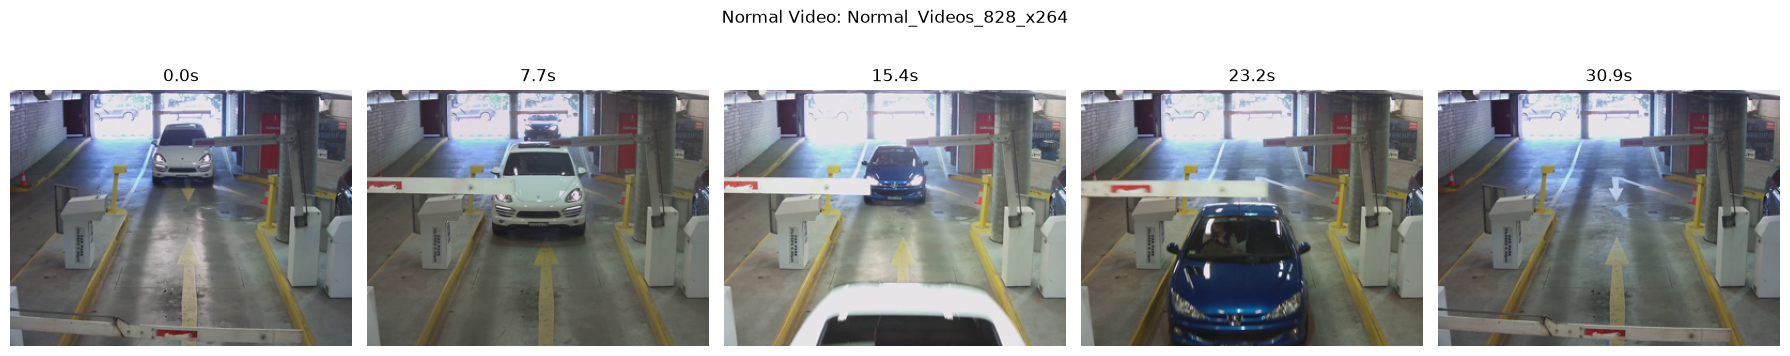

In [11]:
normal_path = resolve_video_path(
    normal_video["file_path"]
)

normal_frames = sample_video_frames(
    video_path=normal_path,
    duration_seconds=normal_video["duration_seconds"],
    number_of_frames=5,
)

plot_frames(
    frames=normal_frames,
    title=f"Normal Video: {normal_video['video_id']}",
)

#### Inspect several anomaly categories

In [12]:
selected_categories = [
    "Abuse",
    "Arrest",
    "Burglary",
    "Robbery",
    "RoadAccidents",
    "Shooting",
]

available_categories = set(
    video_splits["category"].unique()
)

selected_categories = [
    category
    for category in selected_categories
    if category in available_categories
]

selected_categories

['Abuse', 'Arrest', 'Burglary', 'Robbery', 'RoadAccidents', 'Shooting']

In [13]:
anomaly_examples = (
    video_splits[
        (video_splits["category"].isin(selected_categories))
        & (video_splits["split"] == "train")
    ]
    .groupby(
        "category",
        group_keys=False,
    )
    .sample(
        n=1,
        random_state=42,
    )
)

anomaly_examples[
    [
        "video_id",
        "category",
        "duration_seconds",
        "fps",
        "width",
        "height",
    ]
]

,video_id,category,duration_seconds,fps,width,height
232,Abuse017_x264A,Abuse,64.000,30.0,320,240
297,Arrest016_x264,Arrest,352.867,30.0,320,240
529,Burglary031_x264,Burglary,208.567,30.0,320,240
836,RoadAccidents100_x264,RoadAccidents,18.067,30.0,320,240
929,Robbery086_x264,Robbery,240.133,30.0,320,240
996,Shooting015_x264,Shooting,57.100,30.0,320,240


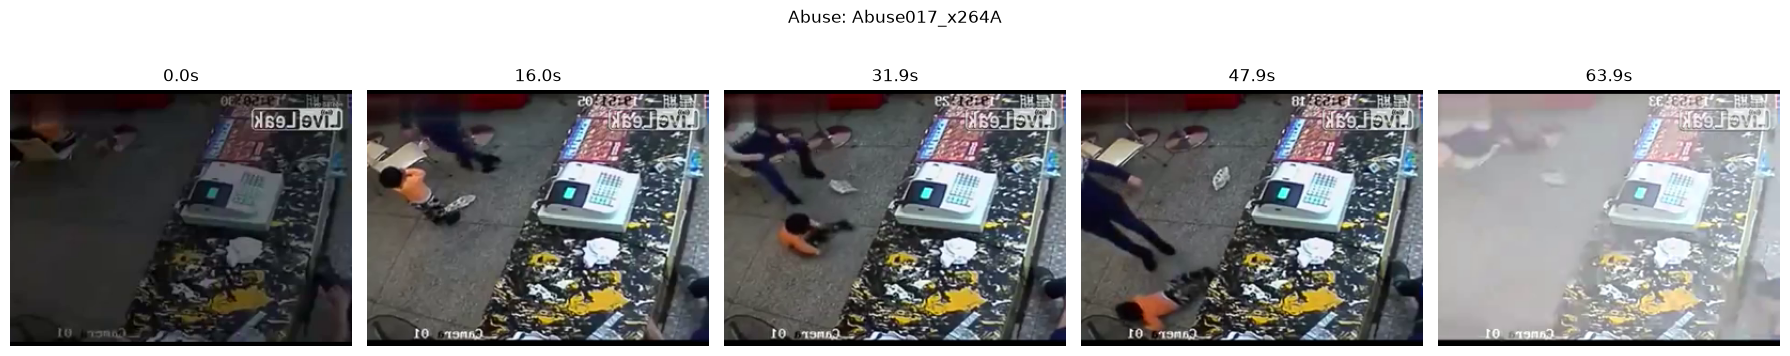

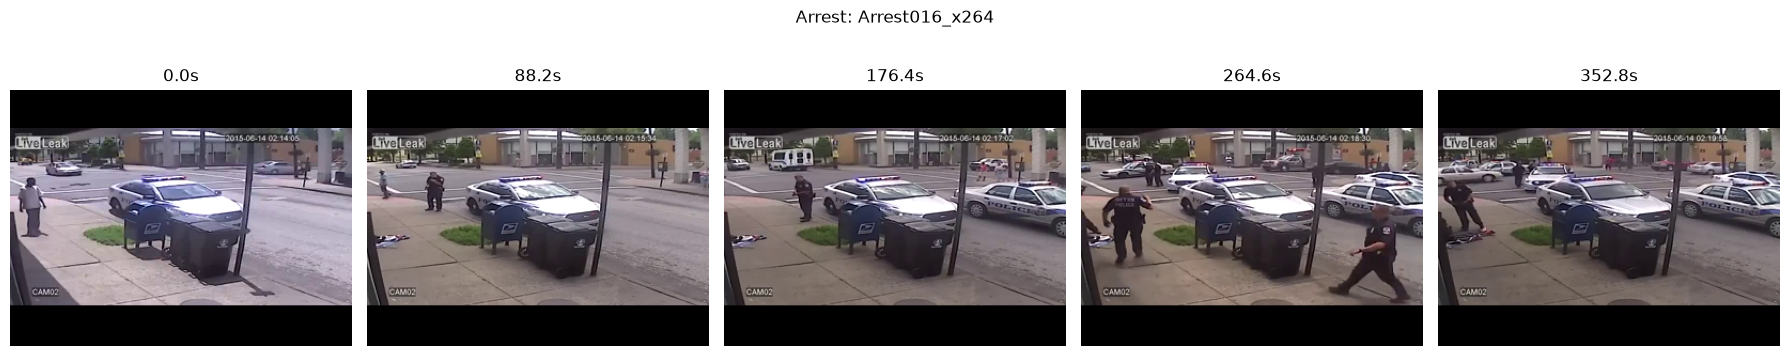

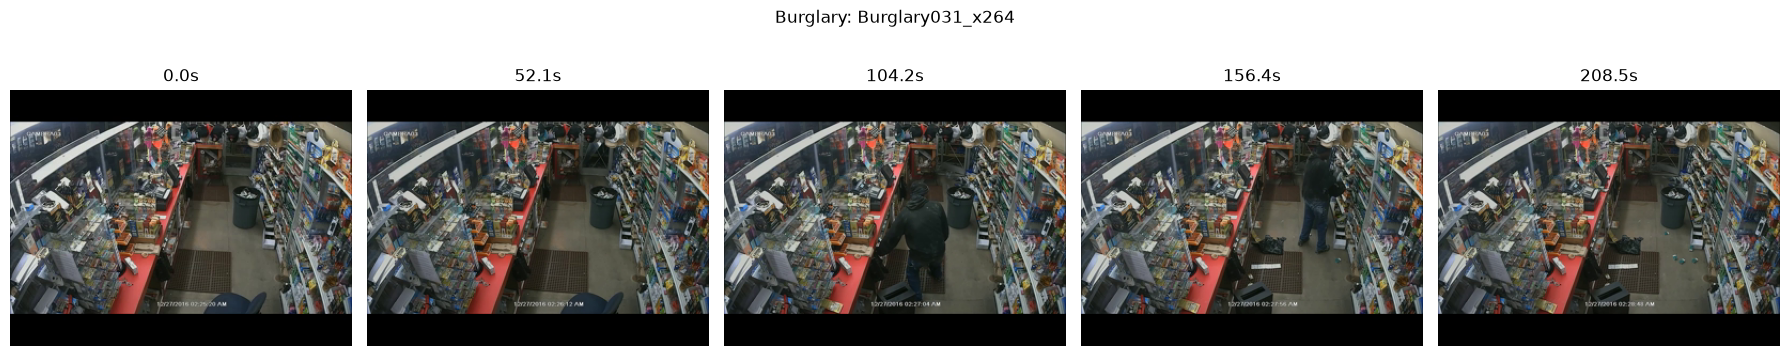

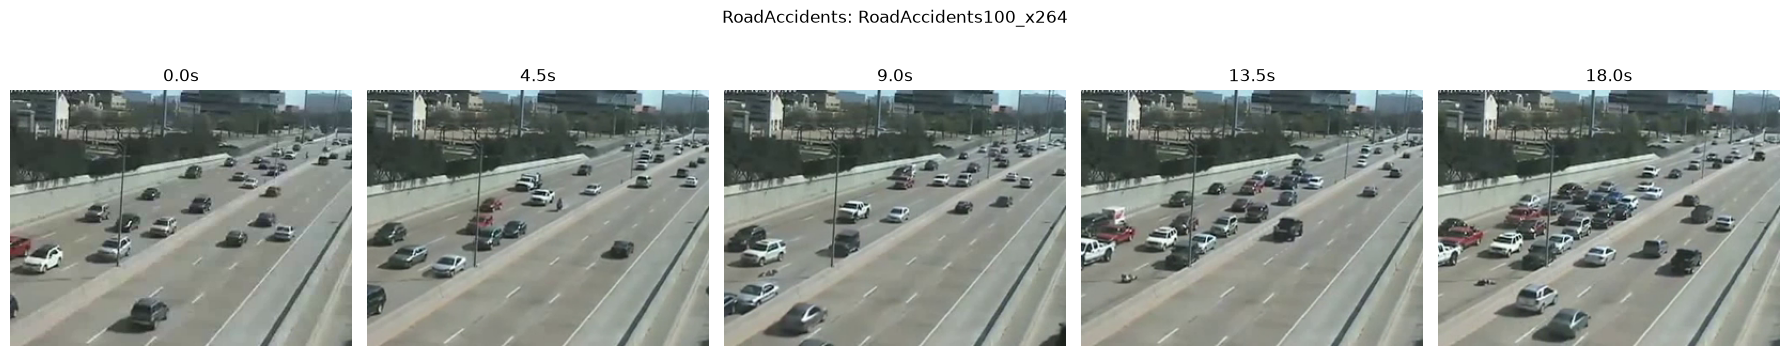

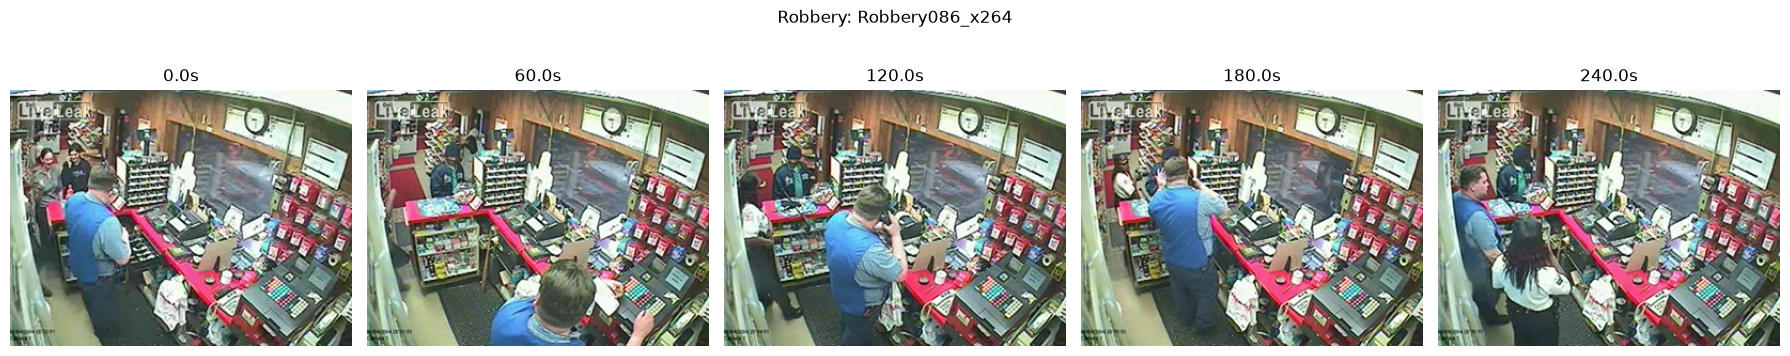

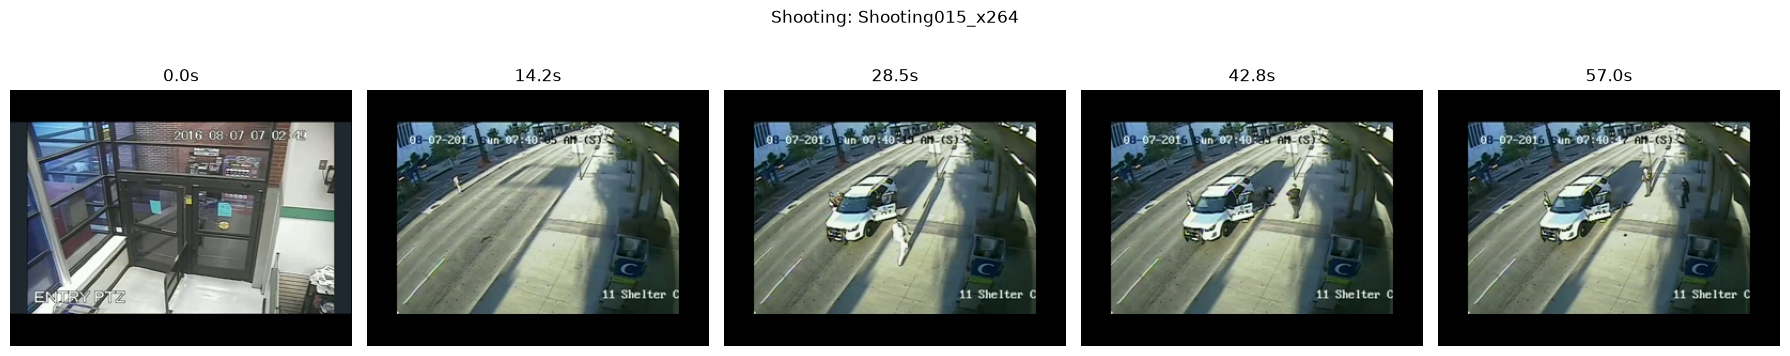

In [14]:
for row in anomaly_examples.itertuples(index=False):
    video_path = resolve_video_path(
        row.file_path
    )

    frames = sample_video_frames(
        video_path=video_path,
        duration_seconds=row.duration_seconds,
        number_of_frames=5,
    )

    plot_frames(
        frames=frames,
        title=f"{row.category}: {row.video_id}",
    )

#### Inspect timeline of one anomalous video

In [15]:
anomalous_video = (
    video_splits[
        (video_splits["binary_label"] == 1)
        & (video_splits["split"] == "train")
    ]
    .sample(
        n=1,
        random_state=7,
    )
    .iloc[0]
)

anomalous_video[
    [
        "video_id",
        "category",
        "duration_seconds",
        "fps",
    ]
]

video_id            Stealing079_x264
category                    Stealing
duration_seconds             194.867
fps                             30.0
Name: 1128, dtype: object

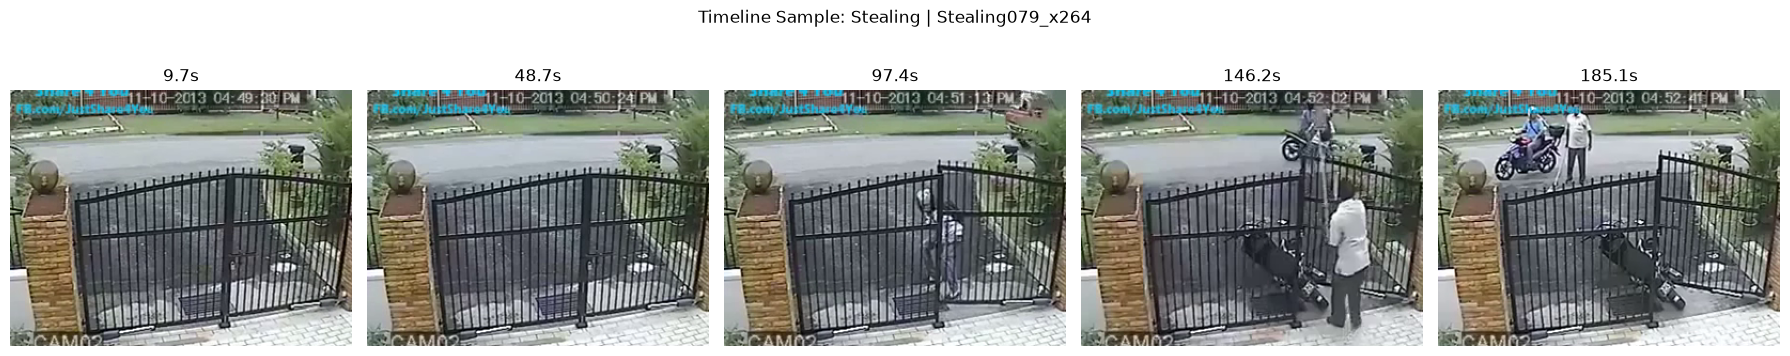

In [16]:
anomalous_path = resolve_video_path(
    anomalous_video["file_path"]
)

duration = float(
    anomalous_video["duration_seconds"]
)

timestamps = [
    0.05 * duration,
    0.25 * duration,
    0.50 * duration,
    0.75 * duration,
    0.95 * duration,
]

timeline_frames = []

for timestamp in timestamps:
    frame = read_frame_at_time(
        video_path=anomalous_path,
        timestamp_seconds=timestamp,
    )

    if frame is not None:
        timeline_frames.append(
            (
                timestamp,
                frame,
            )
        )

plot_frames(
    frames=timeline_frames,
    title=(
        f"Timeline Sample: "
        f"{anomalous_video['category']} | "
        f"{anomalous_video['video_id']}"
    ),
)

#### Inspect one real 4-second clip

In [17]:
clip_example = (
    clip_manifest[
        clip_manifest["split"] == "train"
    ]
    .sample(
        n=1,
        random_state=42,
    )
    .iloc[0]
)

clip_example[
    [
        "clip_id",
        "video_id",
        "category",
        "start_seconds",
        "end_seconds",
        "split",
    ]
]

clip_id          Robbery027_x264_clip_00041
video_id                    Robbery027_x264
category                            Robbery
start_seconds                         164.0
end_seconds                           168.0
split                                 train
Name: 28776, dtype: object

In [18]:
def sample_clip_frames(
    video_path: str | Path,
    start_seconds: float,
    end_seconds: float,
    number_of_frames: int = 8,
) -> list[tuple[float, np.ndarray]]:
    """
    Sample frames inside one clip window.
    """
    if end_seconds <= start_seconds:
        return []

    timestamps = np.linspace(
        start_seconds,
        max(end_seconds - 0.05, start_seconds),
        number_of_frames,
    )

    frames = []

    for timestamp in timestamps:
        frame = read_frame_at_time(
            video_path=video_path,
            timestamp_seconds=float(timestamp),
        )

        if frame is not None:
            frames.append(
                (
                    float(timestamp),
                    frame,
                )
            )

    return frames

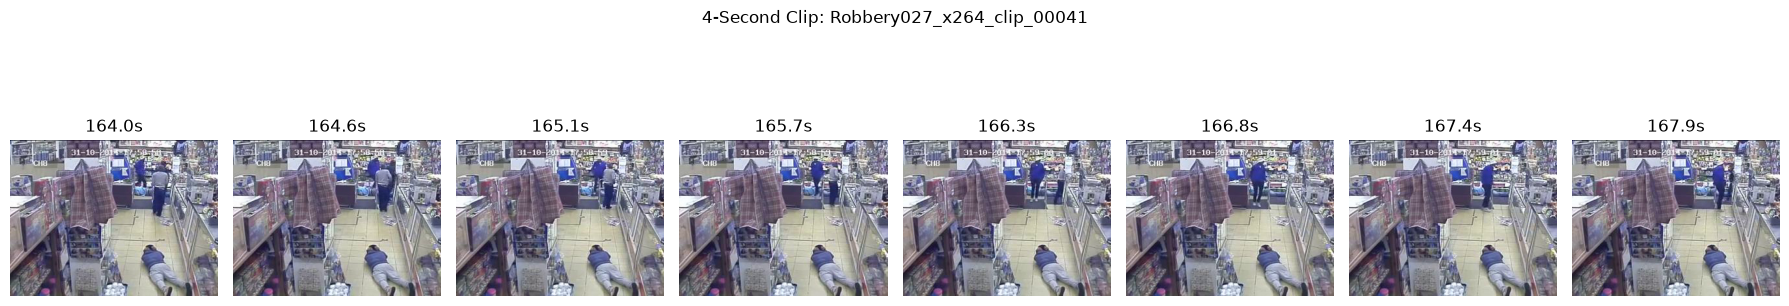

In [19]:
clip_path = resolve_video_path(
    clip_example["file_path"]
)

clip_frames = sample_clip_frames(
    video_path=clip_path,
    start_seconds=clip_example["start_seconds"],
    end_seconds=clip_example["end_seconds"],
    number_of_frames=8,
)

plot_frames(
    frames=clip_frames,
    title=f"4-Second Clip: {clip_example['clip_id']}",
)

#### Simple motion diagnostic

In [20]:
def mean_frame_difference(
    frames: list[np.ndarray],
) -> float:
    """
    Compute average pixel difference between consecutive frames.
    """
    if len(frames) < 2:
        return 0.0

    differences = []

    for current_frame, next_frame in zip(
        frames[:-1],
        frames[1:],
    ):
        current_gray = cv2.cvtColor(
            current_frame,
            cv2.COLOR_RGB2GRAY,
        )

        next_gray = cv2.cvtColor(
            next_frame,
            cv2.COLOR_RGB2GRAY,
        )

        if current_gray.shape != next_gray.shape:
            next_gray = cv2.resize(
                next_gray,
                (
                    current_gray.shape[1],
                    current_gray.shape[0],
                ),
            )

        difference = np.mean(
            np.abs(
                current_gray.astype(np.float32)
                - next_gray.astype(np.float32)
            )
        )

        differences.append(difference)

    return float(np.mean(differences))

In [21]:
frame_arrays = [
    frame
    for _, frame in clip_frames
]

motion_score = mean_frame_difference(
    frame_arrays
)

print(f"Mean frame difference: {motion_score:.3f}")

Mean frame difference: 4.365


#### Compare motion across 20 clips

In [22]:
clip_sample = (
    clip_manifest[
        clip_manifest["split"] == "train"
    ]
    .sample(
        n=20,
        random_state=42,
    )
)

motion_records = []

for row in clip_sample.itertuples(index=False):
    video_path = resolve_video_path(
        row.file_path
    )

    frames = sample_clip_frames(
        video_path=video_path,
        start_seconds=row.start_seconds,
        end_seconds=row.end_seconds,
        number_of_frames=6,
    )

    frame_arrays = [
        frame
        for _, frame in frames
    ]

    motion_score = mean_frame_difference(
        frame_arrays
    )

    motion_records.append(
        {
            "clip_id": row.clip_id,
            "video_id": row.video_id,
            "category": row.category,
            "motion_score": motion_score,
        }
    )

motion_df = pd.DataFrame(motion_records)

motion_df.sort_values(
    "motion_score",
    ascending=False,
).head()

,clip_id,video_id,category,motion_score
10,Vandalism022_x264_clip_00019,Vandalism022_x264,Vandalism,27.706146
11,Assault003_x264_clip_00029,Assault003_x264,Assault,14.831357
4,Burglary084_x264_clip_00034,Burglary084_x264,Burglary,11.455678
5,Assault034_x264_clip_00006,Assault034_x264,Assault,11.084836
1,RoadAccidents023_x264_clip_00006,RoadAccidents023_x264,RoadAccidents,8.510813


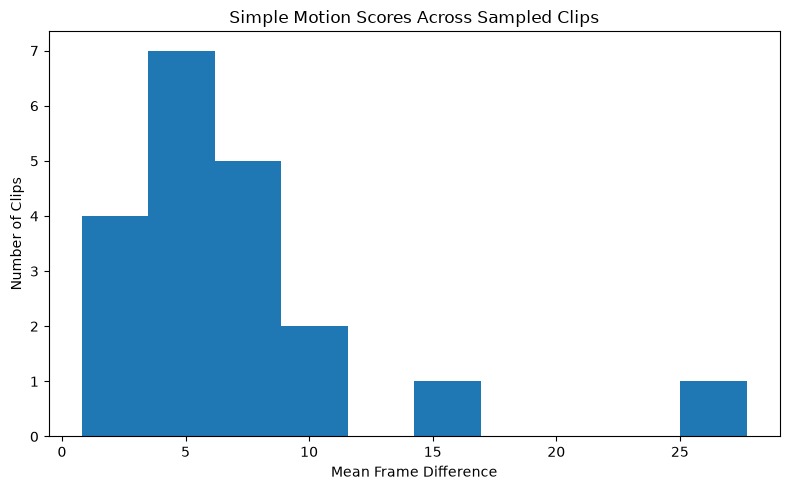

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    motion_df["motion_score"],
    bins=10,
)

plt.title("Simple Motion Scores Across Sampled Clips")
plt.xlabel("Mean Frame Difference")
plt.ylabel("Number of Clips")
plt.tight_layout()
plt.show()

# Conclusion

Notebook 02 inspected real video content from the SentinelVision AI dataset.

## What we did

We:

- loaded the frozen video and clip metadata,
- decoded real frames from source videos,
- inspected normal surveillance footage,
- inspected multiple anomaly categories,
- sampled an anomalous video across its timeline,
- inspected a real 4-second clip window,
- measured simple frame-to-frame visual change.

## Main findings

### 1. The dataset is visually diverse

Videos differ by camera angle, environment, lighting, resolution, and motion.

### 2. Anomalous videos are weakly labeled

A video labeled anomalous may contain normal-looking sections.

Therefore, the source-level binary label should not be treated as perfect clip-level ground truth.

### 3. Motion alone is not enough

High motion can happen in normal videos, and low motion can happen during subtle anomalies.

### 4. Preprocessing must standardize video input

The next phase must convert clips into consistent model-ready features.

## Decisions for the next notebook

Notebook 03 will create reusable clip embeddings.

The next flow is:

`clip manifest → frame sampling → resize frames → feature extraction → save embeddings`

These embeddings will feed the baseline anomaly models.